# FCNN - Customer Churn Prediction
نسخة مطبّقة من نفس منهجية نوت بوك الـ Concrete (FCNN + Evaluation) على بيانات Churn Modelling.

**ملاحظة عن التكييف:** الفرق الأساسي هنا إن الهدف (`Exited`) قيمة ثنائية (0 أو 1) - يعني هي مسألة **تصنيف (Classification)** مش انحدار (Regression) زي داتا الخرسانة أو الشقق. علشان كده:
- طبقة الإخراج بقت `sigmoid` بدل `linear`
- دالة الخسارة `binary_crossentropy` بدل `mean_squared_error`
- مقياس التقييم بقى `accuracy` / `confusion matrix` بدل `r2_score` (لأن R² غير منطقي لمشكلة تصنيف)
باقي الخطوات (scaling, boxplot, pairplot, train/test split, إزالة الـ outliers بطريقة IQR, بناء نموذجين للمقارنة) اتطبقت بنفس الأسلوب بالظبط.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
Data = pd.read_csv('Churn_Modelling.csv')
Data.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## تنظيف الأعمدة
- تم حذف `RowNumber`, `CustomerId`, `Surname` لأنها معرّفات (identifiers) مالهاش قيمة تنبؤية
- تم عمل One-Hot Encoding لعمودي `Geography` و `Gender` لتحويلهم لأرقام

In [4]:
df = Data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

geo_dummies = pd.get_dummies(df['Geography'], prefix='Geo', drop_first=True)
gender_dummies = pd.get_dummies(df['Gender'], prefix='Gender', drop_first=True)

HDNames = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard',
           'IsActiveMember','EstimatedSalary'] + list(geo_dummies.columns) + list(gender_dummies.columns) + ['Exited']

Data = pd.concat([
    df.drop(columns=['Geography', 'Gender', 'Exited']),
    geo_dummies, gender_dummies,
    df[['Exited']]
], axis=1)

Data = Data.astype(float)
Data.columns = HDNames
Data.head(20)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geo_Germany,Geo_Spain,Gender_Male,Exited
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,0.0,0.0,0.0,1.0
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0,1.0,0.0,0.0
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,0.0,0.0,0.0,1.0
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0,0.0,0.0,0.0
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0,1.0,0.0,0.0
5,645.0,44.0,8.0,113755.78,2.0,1.0,0.0,149756.71,0.0,1.0,1.0,1.0
6,822.0,50.0,7.0,0.00,2.0,1.0,1.0,10062.80,0.0,0.0,1.0,0.0
7,376.0,29.0,4.0,115046.74,4.0,1.0,0.0,119346.88,1.0,0.0,0.0,1.0
8,501.0,44.0,4.0,142051.07,2.0,0.0,1.0,74940.50,0.0,0.0,1.0,0.0
9,684.0,27.0,2.0,134603.88,1.0,1.0,1.0,71725.73,0.0,0.0,1.0,0.0


In [5]:
summary = Data.describe()
print(summary)

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary   Geo_Germany  \
count  10000.00000    10000.000000     10000.000000  10000.000000   
mean       0.70550        0.515100    100090.239881      0.250900   
std        0.45584        0.499797     57510.492818      0.4335

# boxplot is a graphical representation used to describe the distribution of a sample by simple dispersion and position indexes

<Axes: >

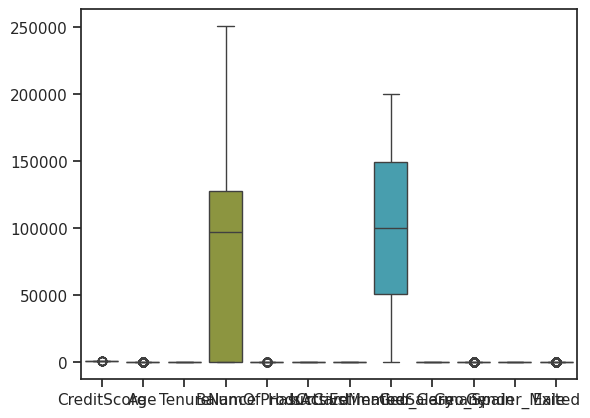

In [6]:
sns.set(style="ticks")
sns.boxplot(data=Data)

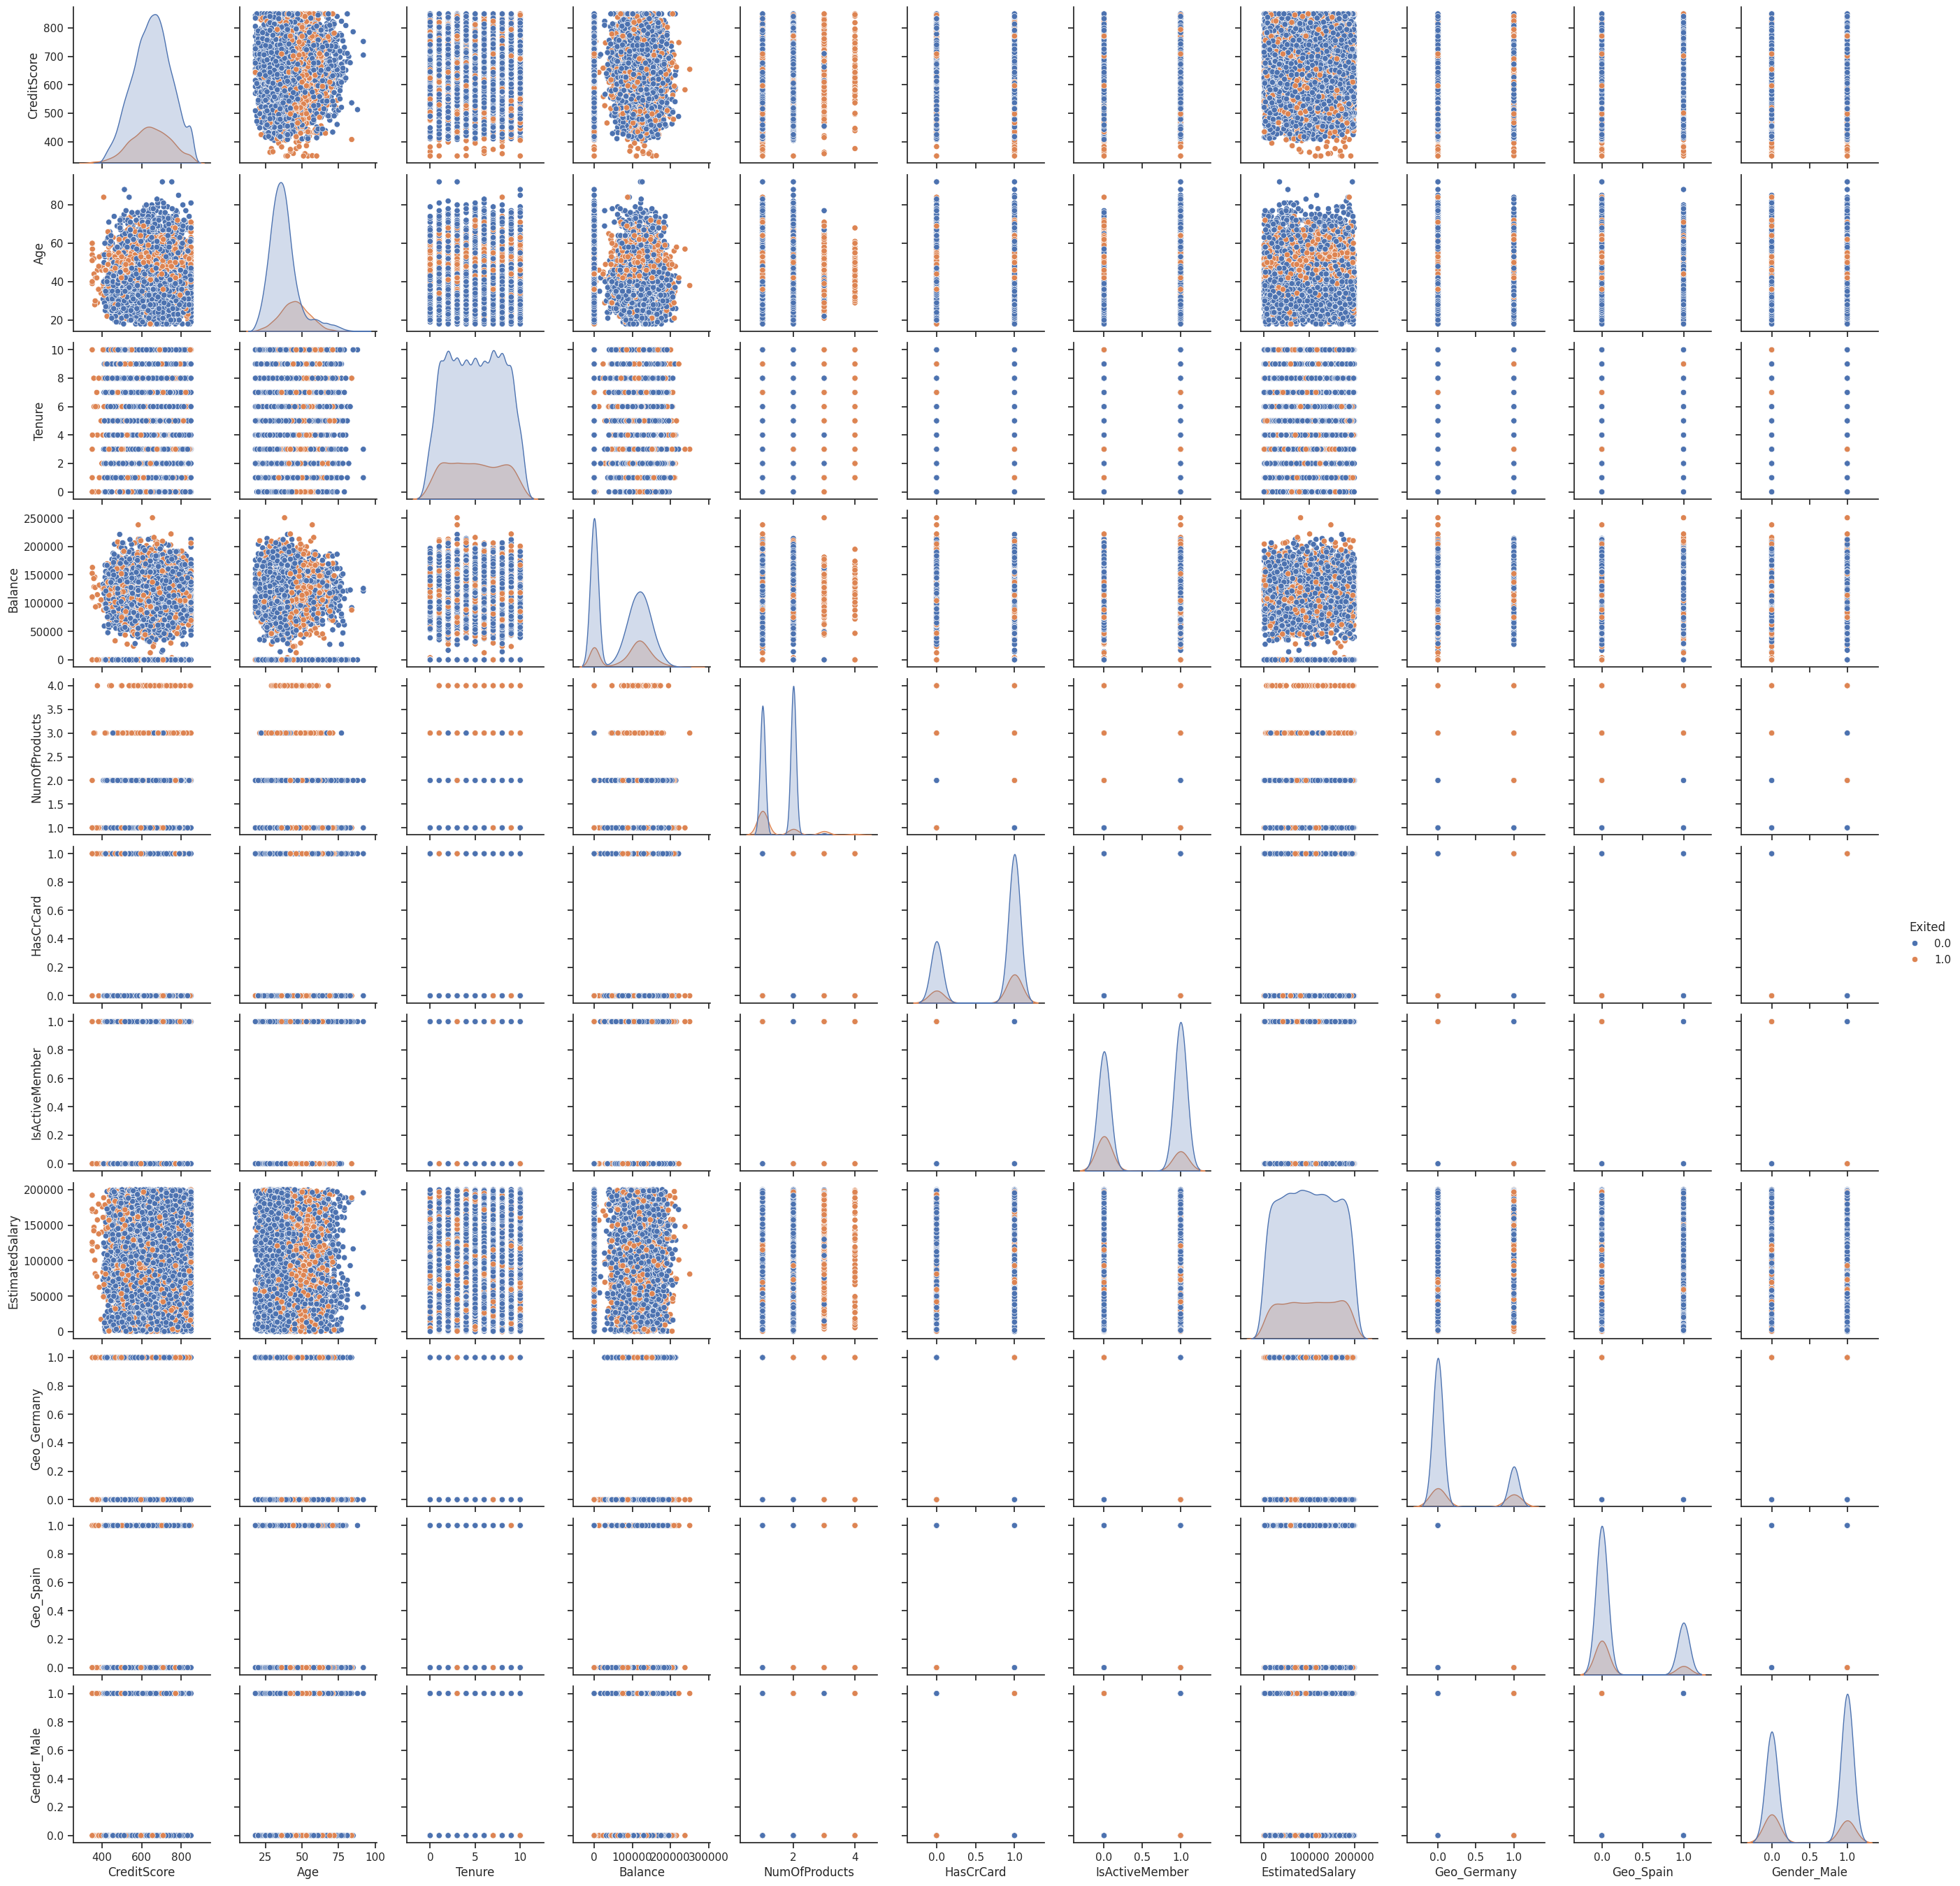

In [7]:
sns.pairplot(data=Data, hue='Exited')

x(scaled) = (x-x(min)/(x(max)-x(min)))

**ملاحظة:** عمود الهدف `Exited` اتسحب من عملية الـ scaling لأنه أصلًا 0/1 وهدفنا للتصنيف، فمفيش داعي نطبّق عليه MinMaxScaler.

In [8]:
from sklearn.preprocessing import MinMaxScaler
n_features = len(HDNames) - 1
scaler = MinMaxScaler()
print(scaler.fit(Data.iloc[:, :n_features]))

MinMaxScaler()


In [9]:
PredictorsScaled = scaler.fit_transform(Data.iloc[:, :n_features])
DataScaled = pd.DataFrame(PredictorsScaled, columns=HDNames[:n_features])
DataScaled['Exited'] = Data['Exited'].values

In [10]:
summary = DataScaled.describe()
print(summary)

        CreditScore           Age        Tenure       Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000  10000.000000   10000.000000   
mean       0.601058      0.282727      0.501280      0.304848       0.176733   
std        0.193307      0.141727      0.289217      0.248696       0.193885   
min        0.000000      0.000000      0.000000      0.000000       0.000000   
25%        0.468000      0.189189      0.300000      0.000000       0.000000   
50%        0.604000      0.256757      0.500000      0.387402       0.000000   
75%        0.736000      0.351351      0.700000      0.508749       0.333333   
max        1.000000      1.000000      1.000000      1.000000       1.000000   

         HasCrCard  IsActiveMember  EstimatedSalary   Geo_Germany  \
count  10000.00000    10000.000000     10000.000000  10000.000000   
mean       0.70550        0.515100         0.500441      0.250900   
std        0.45584        0.499797         0.287580      0.433553   
min

<Axes: >

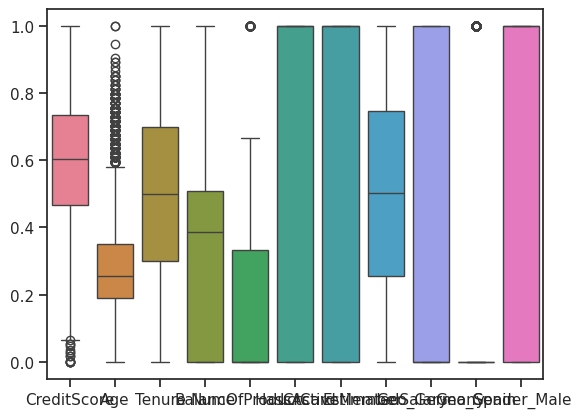

In [11]:
sns.boxplot(data=DataScaled.iloc[:, :n_features])

In [12]:
from sklearn.model_selection import train_test_split
Predictors = pd.DataFrame(DataScaled.iloc[:, :n_features])
Response = pd.DataFrame(DataScaled.iloc[:, n_features])

In [13]:
Pred_train, Pred_test, Resp_train, Resp_test = train_test_split(Predictors, Response, test_size=0.2, random_state=1) #20% من الداتا يتقسم كـ test data

print(Pred_train.shape)
print(Pred_test.shape)
print(Resp_train.shape)
print(Resp_test.shape)

(8000, 11)
(2000, 11)
(8000, 1)
(2000, 1)


1. Import the Sequential from keras.models
1. Stack layers using the .add() method
2. Configure the learning process using .compile() method
2. Train the model on train dataset using .fit() method

In [14]:
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Dropout, Input
from keras.optimizers import Adam, SGD, RMSprop

# fully connected neural network with 4 levels (2 hidden layers)
model = Sequential()

model.add(Input(shape=(n_features,)))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # sigmoid لأن دي مشكلة تصنيف ثنائي

I0000 00:00:1786565029.052089    3438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786565029.057769    3438 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786565029.539354    3438 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786565033.579119    3438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786565033.582078    3438 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1786565034.214365    3438 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

1. adam optimizer: خوارزمية تحسين قائمة على الـ gradient بمعدل تعلم تكيفي
2. binary_crossentropy loss function: دالة الخسارة القياسية لمشاكل التصنيف الثنائي
1. accuracy metric: نسبة التنبؤات الصحيحة، مقياس منطقي هنا لأن الهدف قيمة ثنائية (0/1)

In [17]:
history = model.fit(Pred_train, Resp_train, epochs=100, verbose=1, validation_split=0.2, batch_size=128)

Epoch 1/100


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:10 1s/step - accuracy: 0.2109 - loss: 0.7662

27/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4673 - loss: 0.7062 

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6178 - loss: 0.6685 - val_accuracy: 0.7975 - val_loss: 0.5918


Epoch 2/100


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8653 - loss: 0.3296 - val_accuracy: 0.8512 - val_loss: 0.3594


Epoch 100/100


 1/50 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9062 - loss: 0.2432

31/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3304  

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8664 - loss: 0.3284 - val_accuracy: 0.8512 - val_loss: 0.3607


## تقييم النموذج
بدل R-squared (اللي بيستخدم لمشاكل الانحدار) استخدمنا **Accuracy** و **Confusion Matrix** لأنها المقاييس المناسبة لمشكلة تصنيف ثنائي.

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_prob = model.predict(Pred_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print('Accuracy of Keras Model')
print(accuracy_score(Resp_test, y_pred))
print(confusion_matrix(Resp_test, y_pred))
print(classification_report(Resp_test, y_pred))

 1/63 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step

44/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Accuracy of Keras Model
0.86
[[1516   69]
 [ 211  204]]
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      1585
         1.0       0.75      0.49      0.59       415

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



Outlier distort data analysis result

---
We will use Tukey's method which will use the interquartile range (IQR) approach

---

In [19]:
Q1 = DataScaled.iloc[:, :n_features].quantile(0.25)
Q3 = DataScaled.iloc[:, :n_features].quantile(0.75)
IQR = Q3-Q1
print(IQR)

CreditScore        0.268000
Age                0.162162
Tenure             0.400000
Balance            0.508749
NumOfProducts      0.333333
HasCrCard          1.000000
IsActiveMember     1.000000
EstimatedSalary    0.491978
Geo_Germany        1.000000
Geo_Spain          0.000000
Gender_Male        1.000000
dtype: float64


In [20]:
mask = ~((DataScaled.iloc[:, :n_features] < (Q1 - 1.5 * IQR)) | (DataScaled.iloc[:, :n_features] > (Q3 + 1.5 * IQR))).any(axis=1)
DataScaledOut = DataScaled[mask]
DataScaledOut.shape

(7158, 12)

Text(0.5, 1.0, 'Data without outliers')

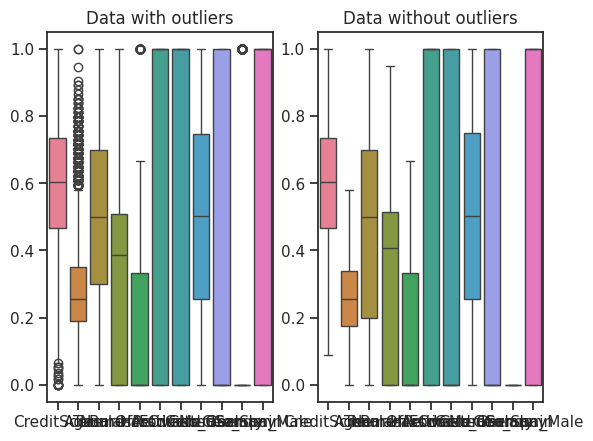

In [21]:
plt.figure(1)
plt.subplot(121)
sns.boxplot(data=DataScaled.iloc[:, :n_features])
plt.title("Data with outliers")

plt.subplot(122)
sns.boxplot(data=DataScaledOut.iloc[:, :n_features])
plt.title("Data without outliers")

In [22]:
Predictors2 = pd.DataFrame(DataScaledOut.iloc[:, :n_features])
Response2 = pd.DataFrame(DataScaledOut.iloc[:, n_features])

In [23]:
Pred_train2, Pred_test2, Resp_train2, Resp_test2 = train_test_split(Predictors2, Response2, test_size=0.2, random_state=1)
print(Pred_train2.shape)
print(Pred_test2.shape)
print(Resp_train2.shape)
print(Resp_test2.shape)

(5726, 11)
(1432, 11)
(5726, 1)
(1432, 1)


In [24]:
# fully connected neural network with 4 levels (2 hidden layers) - بدون outliers
model2 = Sequential()
model2.add(Input(shape=(n_features,)))
model2.add(Dense(20, activation='relu'))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

In [25]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model2.fit(Pred_train2, Resp_train2, epochs=100, verbose=1)

Epoch 1/100


  1/179 ━━━━━━━━━━━━━━━━━━━━ 3:55 1s/step - accuracy: 0.5312 - loss: 0.6937

 29/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7629 - loss: 0.6636 

 59/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7823 - loss: 0.6337

 88/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7752 - loss: 0.6101

...

 86/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8652 - loss: 0.3288

115/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8579 - loss: 0.3417

145/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8565 - loss: 0.3404

175/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8546 - loss: 0.3399

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3417


In [28]:
y_pred_prob2 = model2.predict(Pred_test2)
y_pred2 = (y_pred_prob2 > 0.5).astype(int)

 1/45 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
print('Accuracy of Neural Network Model without outliers')
print(accuracy_score(Resp_test2, y_pred2))
print(confusion_matrix(Resp_test2, y_pred2))

Accuracy of Neural Network Model without outliers
0.8582402234636871
[[1077   74]
 [ 129  152]]


Text(0.5, 1.0, 'Data with outliers')

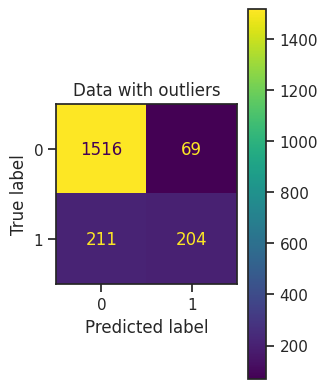

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(1)
plt.subplot(121)
ConfusionMatrixDisplay(confusion_matrix(Resp_test, y_pred)).plot(ax=plt.gca())
plt.title("Data with outliers")

Text(0.5, 1.0, 'Data without outliers')

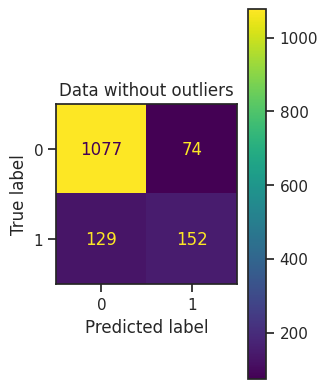

In [31]:
plt.subplot(122)
ConfusionMatrixDisplay(confusion_matrix(Resp_test2, y_pred2)).plot(ax=plt.gca())
plt.title("Data without outliers")